# Assignment 8 — CNN Image Classification with PyTorch
## FashionMNIST with Custom Smartphone Images

**Name:** `Md Abir Hossain`  
**Student ID:** `220144`  
**Course:** AI/ML Lab  
**Dataset:** FashionMNIST  
**GitHub Repository:** `https://github.com/abir945/AI_ML_LAB`  
**Custom Dataset Directory:** `CNN/dataset/`  
**Saved Model:** `CNN/model/220144.pth`

---

## Assignment Overview

This assignment implements a complete Convolutional Neural Network (CNN) image classification pipeline using PyTorch. The model is trained on the standard FashionMNIST dataset and subsequently evaluated on ten custom smartphone images representing the corresponding FashionMNIST classes.

The complete workflow is designed to run automatically in Google Colab. The standard dataset is downloaded using `torchvision.datasets`, while the custom images and trained model are retrieved automatically from the public GitHub repository.

### Workflow

1. Automatically clone the public GitHub repository.
2. Load the ten custom smartphone images from `CNN/dataset/`.
3. Download the FashionMNIST dataset automatically using `torchvision.datasets`.
4. Apply image preprocessing, including grayscale conversion, resizing to 28×28 pixels, tensor conversion, and normalization using FashionMNIST statistics.
5. Build a three-block CNN using `Conv2d`, `BatchNorm`, `ReLU`, `MaxPool2d`, `Dropout`, and `Linear` layers.
6. Train the model for 10 epochs using `CrossEntropyLoss` and the Adam optimizer.
7. Record training and validation loss and accuracy throughout the training process.
8. Save the trained model state dictionary as `220144.pth`.
9. Generate the required visualizations, including:
   - Loss vs. Epochs
   - Accuracy vs. Epochs
   - Confusion Matrix
   - Classification Report
   - Visual Error Analysis using three randomly selected misclassified test images
10. Preprocess the custom smartphone images to reduce the difference between real-world photographs and the FashionMNIST image format.
11. Classify the ten custom images using the trained CNN.
12. Apply Softmax to obtain the predicted class probabilities and confidence scores.
13. Display the custom image predictions in a 2×5 prediction gallery.

### Custom Image Processing

Real-world smartphone images differ from FashionMNIST images in terms of resolution, background, lighting, and image composition. Therefore, the custom images are processed before classification using:

`EXIF Rotation Correction → Grayscale Conversion → Background Adjustment → Object Cropping → Contrast Enhancement → Resize to 28×28 → Tensor Conversion → Normalization`

The final preprocessing pipeline converts the custom images into a format compatible with the trained CNN.

### Automatic Custom Image Loading

The custom-image loader automatically detects supported image files from the `CNN/dataset/` directory. Therefore, image loading does not depend on manually entering individual file paths.

When a filename contains a recognizable FashionMNIST class name, the corresponding true label can also be identified for comparison with the model prediction.


In [1]:
# ============================================================
# 0. CONFIGURATION
# ============================================================

STUDENT_ID = "220144"

GITHUB_USER = "abir945"
REPO_NAME = "AI_ML_LAB"
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"

# Your GitHub structure
DATASET_RELATIVE_PATH = "CNN/dataset"
MODEL_RELATIVE_PATH = f"CNN/model/{STUDENT_ID}.pth"

# Assignment training settings
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
VAL_FRACTION = 0.10
SEED = 42

# If the model file already exists:
# False -> train again for the assignment run
# True  -> load the saved state dictionary
FORCE_RETRAIN = True

print("Student ID :", STUDENT_ID)
print("Repository :", REPO_URL)
print("Dataset    :", DATASET_RELATIVE_PATH)
print("Model      :", MODEL_RELATIVE_PATH)


Student ID : 220144
Repository : https://github.com/abir945/AI_ML_LAB.git
Dataset    : CNN/dataset
Model      : CNN/model/220144.pth


In [2]:
# ============================================================
# 1. IMPORTS + REPRODUCIBILITY
# ============================================================

import os
import sys
import json
import time
import random
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device :", device)


PyTorch: 2.11.0+cu128
Device : cuda


In [3]:
# ============================================================
# 2. AUTOMATIC GITHUB REPOSITORY RETRIEVAL
# ============================================================

# When Run All is used in Colab, clone the public repository automatically.

PROJECT_ROOT = Path("/content") / REPO_NAME

if not PROJECT_ROOT.exists():

    print(f"Cloning {REPO_URL} ...")

    result = subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(PROJECT_ROOT)],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        raise RuntimeError(
            "GitHub clone failed. Make sure the repository is PUBLIC.\n\n"
            + result.stderr
        )

else:
    print("✅ Repository already exists.")

DATASET_DIR = PROJECT_ROOT / DATASET_RELATIVE_PATH
MODEL_DIR = PROJECT_ROOT / "CNN" / "model"
WEIGHTS_PATH = PROJECT_ROOT / MODEL_RELATIVE_PATH
DATA_DIR = PROJECT_ROOT / "CNN" / "data"
ASSET_DIR = PROJECT_ROOT / "CNN" / "assets"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_DIR}"
    )

IMAGE_EXTS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

PHOTO_FILES = sorted(
    [
        f for f in DATASET_DIR.iterdir()
        if f.is_file()
        and f.suffix.lower() in IMAGE_EXTS
        and not f.name.startswith(".")
    ],
    key=lambda p: p.name.lower()
)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("Phone photos :", len(PHOTO_FILES))
print("Model path   :", WEIGHTS_PATH)

for i, path in enumerate(PHOTO_FILES, 1):
    print(f"  {i:02d}. {path.name}")

if len(PHOTO_FILES) != 10:
    raise ValueError(
        f"Assignment requires exactly 10 custom images, "
        f"but {len(PHOTO_FILES)} were found in {DATASET_DIR}."
    )


✅ Repository already exists.
PROJECT_ROOT : /content/AI_ML_LAB
Phone photos : 10
Model path   : /content/AI_ML_LAB/CNN/model/220144.pth
  01. 01_t-shirt.png
  02. 02_trouser.jpg
  03. 03_pullover.jpg
  04. 04_dress.jpg
  05. 05_coat.jpg
  06. 06_sandal.jpg
  07. 07_shirt.jpg
  08. 08_sneaker.jpg
  09. 09_bag.jpg
  10. 10_ankle_boot.jpg


## 3. FashionMNIST Classes and Preprocessing

FashionMNIST contains 10 classes:

`T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot`.

The evaluation transform is the single source of truth for standard test images and custom images after the real-world preparation stage. FashionMNIST channel statistics are used for normalization.


In [4]:
# ============================================================
# 3. CLASS NAMES + TRANSFORMS
# ============================================================

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

# Slugs are optional metadata only.
# Prediction itself never depends on the filename.
CLASS_SLUGS = [
    "tshirt",
    "trouser",
    "pullover",
    "dress",
    "coat",
    "sandal",
    "shirt",
    "sneaker",
    "bag",
    "ankleboot",
]

SLUG_TO_IDX = {
    slug: idx
    for idx, slug in enumerate(CLASS_SLUGS)
}

IMG_SIZE = 28
NUM_CLASSES = 10

# FashionMNIST training-split statistics.
FMNIST_MEAN = (0.2860,)
FMNIST_STD = (0.3530,)

# Exact inference transform.
EVAL_TRANSFORM = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        FMNIST_MEAN,
        FMNIST_STD
    ),
])

# Training-only augmentation.
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.08, 0.08),
        scale=(0.92, 1.08)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        FMNIST_MEAN,
        FMNIST_STD
    ),
])

def denormalize(tensor):
    return (
        tensor * FMNIST_STD[0]
        + FMNIST_MEAN[0]
    ).clamp(0, 1)

print("Classes:", CLASS_NAMES)


Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
# ============================================================
# 4. AUTOMATIC FASHIONMNIST DOWNLOAD + SPLIT
# ============================================================

full_train_aug = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=TRAIN_TRANSFORM
)

full_train_eval = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=EVAL_TRANSFORM
)

test_set = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=EVAL_TRANSFORM
)

# Use identical indices for augmented training and deterministic validation.
n_val = int(len(full_train_eval) * VAL_FRACTION)
n_train = len(full_train_eval) - n_val

indices = list(range(len(full_train_eval)))

generator = torch.Generator().manual_seed(SEED)

permutation = torch.randperm(
    len(indices),
    generator=generator
).tolist()

train_idx = permutation[:n_train]
val_idx = permutation[n_train:]

train_set = Subset(full_train_aug, train_idx)
val_set = Subset(full_train_eval, val_idx)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Train      : {len(train_set):,} images")
print(f"Validation : {len(val_set):,} images")
print(f"Test       : {len(test_set):,} images")

sample_images, sample_labels = next(iter(train_loader))

print(
    "One batch  :",
    tuple(sample_images.shape),
    "(batch, channels, height, width)"
)


Train      : 54,000 images
Validation : 6,000 images
Test       : 10,000 images
One batch  : (64, 1, 28, 28) (batch, channels, height, width)


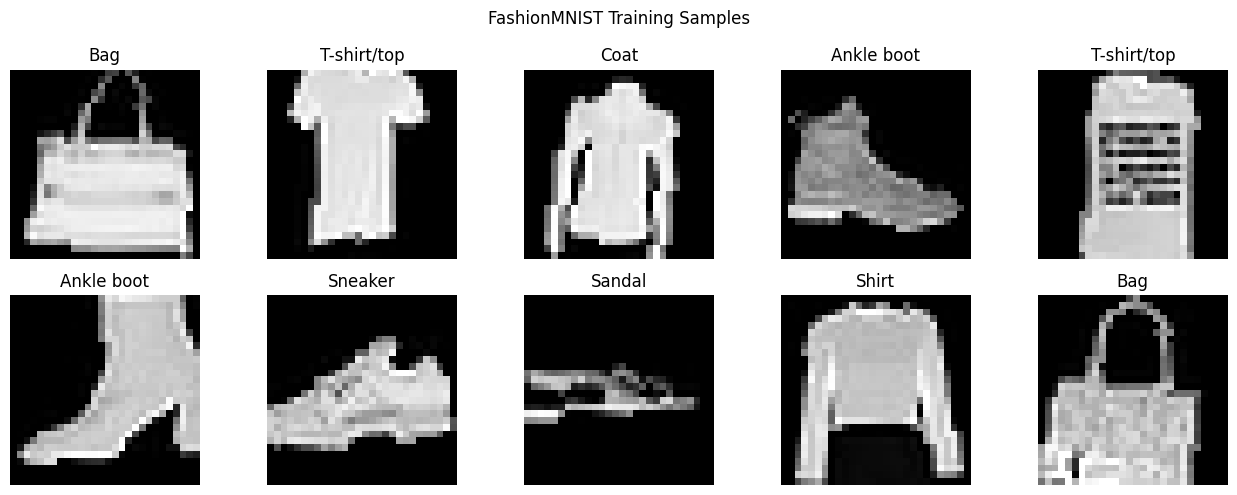

In [6]:
# ============================================================
# 5. SHOW SAMPLE TRAINING IMAGES
# ============================================================

plt.figure(figsize=(13, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    image = denormalize(
        sample_images[i]
    ).squeeze(0).numpy()

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        CLASS_NAMES[
            sample_labels[i].item()
        ]
    )

    plt.axis("off")

plt.suptitle("FashionMNIST Training Samples")
plt.tight_layout()
plt.show()


## 6. CNN Model Architecture

The CNN follows the strong VGG-style structure in the supplied reference notebook:

- Block 1: two Conv2d + BatchNorm + ReLU layers → MaxPool → Dropout
- Block 2: two Conv2d + BatchNorm + ReLU layers → MaxPool → Dropout
- Block 3: Conv2d + BatchNorm + ReLU → MaxPool → Dropout
- Classifier: Flatten → Linear → ReLU → Dropout → Linear

The final layer produces 10 raw class logits.


In [7]:
# ============================================================
# 6. CNN ARCHITECTURE
# ============================================================

class CNN(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES
    ):
        super().__init__()

        self.block1 = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Dropout(0.25)
        )

        self.block2 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Dropout(0.25)
        )

        self.block3 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 3 * 3,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.50),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)

        return x


model = CNN().to(device)

print(model)

parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"\nTotal trainable parameters: "
    f"{parameter_count:,}"
)


CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout

In [8]:
# ============================================================
# 7. LOSS + OPTIMIZER + SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=6,
    gamma=0.3
)

print("Loss      :", criterion)
print("Optimizer :", optimizer.__class__.__name__)
print("Scheduler :", scheduler.__class__.__name__)


Loss      : CrossEntropyLoss()
Optimizer : Adam
Scheduler : StepLR


In [9]:
# ============================================================
# 8. TRAINING UTILITIES
# ============================================================

def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):

    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    seen = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            if training:
                loss.backward()
                optimizer.step()

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        seen += labels.size(0)

    return (
        total_loss / seen,
        correct / seen
    )


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    best_acc = 0.0
    best_state = None

    for epoch in range(
        1,
        epochs + 1
    ):

        start = time.time()

        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(
            train_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        history["lr"].append(
            current_lr
        )

        if val_acc > best_acc:

            best_acc = val_acc

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            best_mark = " ← BEST"

        else:
            best_mark = ""

        elapsed = (
            time.time() - start
        )

        print(
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train Acc {train_acc * 100:6.2f}% | "
            f"Val Loss {val_loss:.4f} | "
            f"Val Acc {val_acc * 100:6.2f}% | "
            f"LR {current_lr:.6f} | "
            f"{elapsed:.1f}s"
            f"{best_mark}"
        )

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return history


print("✅ Training utilities ready.")


✅ Training utilities ready.


In [10]:
# ============================================================
# 9. TRAIN OR LOAD MODEL
# ============================================================

HISTORY_PATH = (
    ASSET_DIR / f"{STUDENT_ID}_history.json"
)

if (
    not FORCE_RETRAIN
    and WEIGHTS_PATH.exists()
    and HISTORY_PATH.exists()
):

    print("Loading existing model and history...")

    try:
        state = torch.load(
            WEIGHTS_PATH,
            map_location=device,
            weights_only=True
        )
    except TypeError:
        state = torch.load(
            WEIGHTS_PATH,
            map_location=device
        )

    model.load_state_dict(
        state
    )

    with open(
        HISTORY_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        history = json.load(
            file
        )

    print("✅ Loaded saved weights and history.")

else:

    print(
        f"Training for {EPOCHS} epochs on {device}..."
    )

    history = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        EPOCHS
    )

    torch.save(
        model.state_dict(),
        WEIGHTS_PATH
    )

    with open(
        HISTORY_PATH,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            history,
            file,
            indent=2
        )

    print(
        "\n✅ Saved model ->",
        WEIGHTS_PATH
    )

    print(
        "✅ Saved history ->",
        HISTORY_PATH
    )

model.to(device)


Training for 10 epochs on cuda...
Epoch 01/10 | Train Loss 0.6885 | Train Acc  74.44% | Val Loss 0.4027 | Val Acc  85.33% | LR 0.001000 | 31.6s ← BEST
Epoch 02/10 | Train Loss 0.4823 | Train Acc  82.20% | Val Loss 0.3584 | Val Acc  87.02% | LR 0.001000 | 25.2s ← BEST
Epoch 03/10 | Train Loss 0.4299 | Train Acc  84.33% | Val Loss 0.3438 | Val Acc  87.55% | LR 0.001000 | 24.8s ← BEST
Epoch 04/10 | Train Loss 0.4010 | Train Acc  85.39% | Val Loss 0.3038 | Val Acc  89.00% | LR 0.001000 | 25.5s ← BEST
Epoch 05/10 | Train Loss 0.3776 | Train Acc  86.34% | Val Loss 0.2706 | Val Acc  89.75% | LR 0.001000 | 24.5s ← BEST
Epoch 06/10 | Train Loss 0.3614 | Train Acc  86.98% | Val Loss 0.2593 | Val Acc  90.50% | LR 0.000300 | 25.5s ← BEST
Epoch 07/10 | Train Loss 0.3217 | Train Acc  88.39% | Val Loss 0.2450 | Val Acc  90.85% | LR 0.000300 | 25.3s ← BEST
Epoch 08/10 | Train Loss 0.3078 | Train Acc  88.97% | Val Loss 0.2384 | Val Acc  91.52% | LR 0.000300 | 26.0s ← BEST
Epoch 09/10 | Train Loss 0.307

CNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout

## 10. Required Training History

The assignment asks for:

- Loss vs Epochs
- Accuracy vs Epochs

Both training and validation curves are shown.


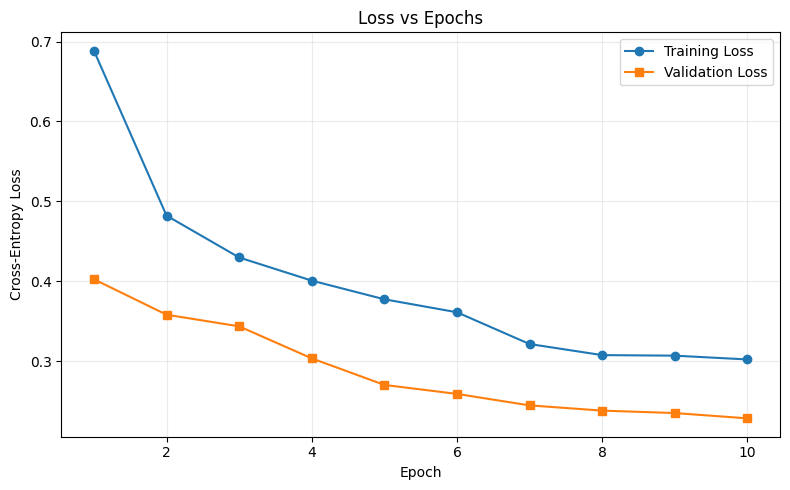

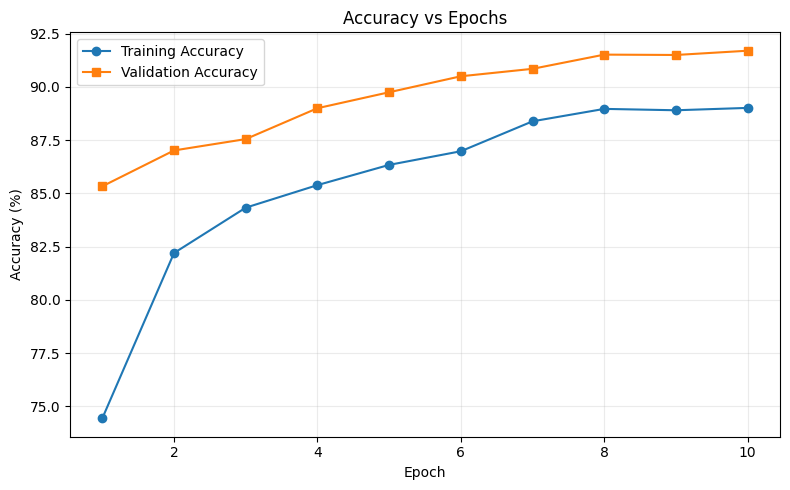

In [11]:
# ============================================================
# 10. TRAINING HISTORY — LOSS + ACCURACY
# ============================================================

epochs_axis = range(
    1,
    len(history["train_loss"]) + 1
)

# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_axis,
    history["train_loss"],
    "o-",
    label="Training Loss"
)

plt.plot(
    epochs_axis,
    history["val_loss"],
    "s-",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Loss vs Epochs")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_axis,
    np.array(history["train_acc"]) * 100,
    "o-",
    label="Training Accuracy"
)

plt.plot(
    epochs_axis,
    np.array(history["val_acc"]) * 100,
    "s-",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epochs")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 11. STANDARD TEST SET EVALUATION
# ============================================================

@torch.no_grad()
def predict_loader(
    model,
    loader
):

    model.eval()

    predictions = []
    targets = []

    for images, labels in loader:

        outputs = model(
            images.to(device)
        )

        preds = outputs.argmax(
            dim=1
        ).cpu().numpy()

        predictions.extend(
            preds.tolist()
        )

        targets.extend(
            labels.numpy().tolist()
        )

    return (
        np.array(predictions),
        np.array(targets)
    )


test_preds, test_targets = (
    predict_loader(
        model,
        test_loader
    )
)

test_accuracy = (
    test_preds == test_targets
).mean()

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"{np.sum(test_preds != test_targets):,} "
    f"of {len(test_targets):,} test images were misclassified."
)


Test Accuracy: 91.75%
825 of 10,000 test images were misclassified.


## 12. Confusion Matrix

The heatmap is calculated on the standard FashionMNIST test set.


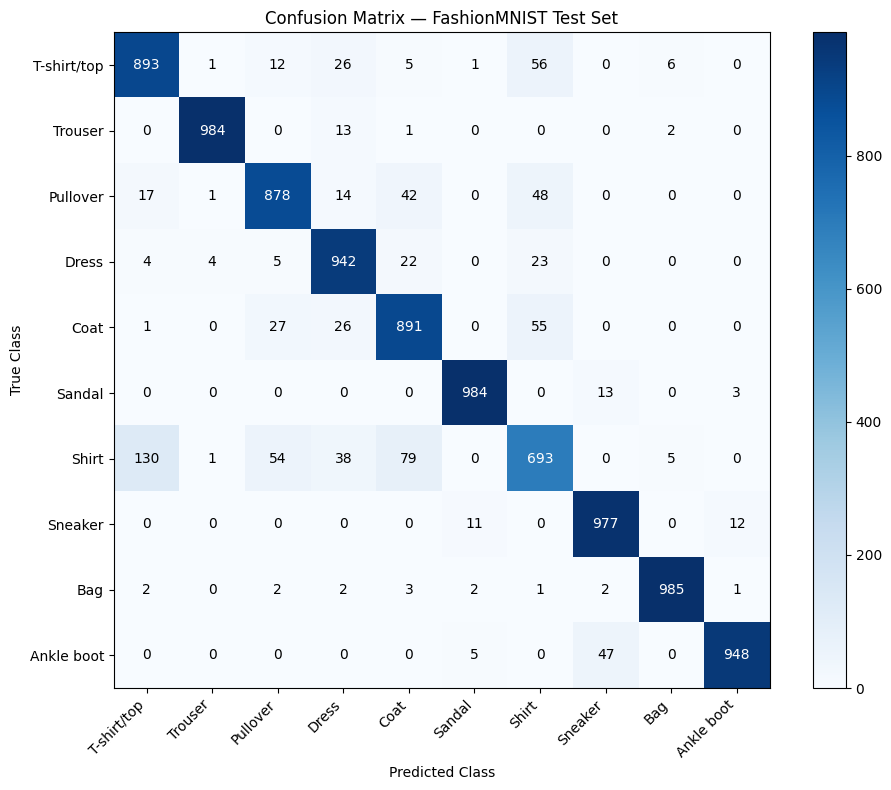


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top     0.8529    0.8930    0.8725      1000
     Trouser     0.9929    0.9840    0.9884      1000
    Pullover     0.8978    0.8780    0.8878      1000
       Dress     0.8878    0.9420    0.9141      1000
        Coat     0.8543    0.8910    0.8722      1000
      Sandal     0.9811    0.9840    0.9825      1000
       Shirt     0.7911    0.6930    0.7388      1000
     Sneaker     0.9403    0.9770    0.9583      1000
         Bag     0.9870    0.9850    0.9860      1000
  Ankle boot     0.9834    0.9480    0.9654      1000

    accuracy                         0.9175     10000
   macro avg     0.9169    0.9175    0.9166     10000
weighted avg     0.9169    0.9175    0.9166     10000



In [13]:
# ============================================================
# 12. CONFUSION MATRIX HEATMAP
# ============================================================

cm = confusion_matrix(
    test_targets,
    test_preds,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10, 8))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix — FashionMNIST Test Set"
)

plt.colorbar()

tick_positions = np.arange(NUM_CLASSES)

plt.xticks(
    tick_positions,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_positions,
    CLASS_NAMES
)

threshold = cm.max() / 2.0

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        test_targets,
        test_preds,
        target_names=CLASS_NAMES,
        digits=4
    )
)


### 12.1 Visual Error Analysis

Three randomly selected test images that the CNN classified incorrectly are shown with true and predicted labels.


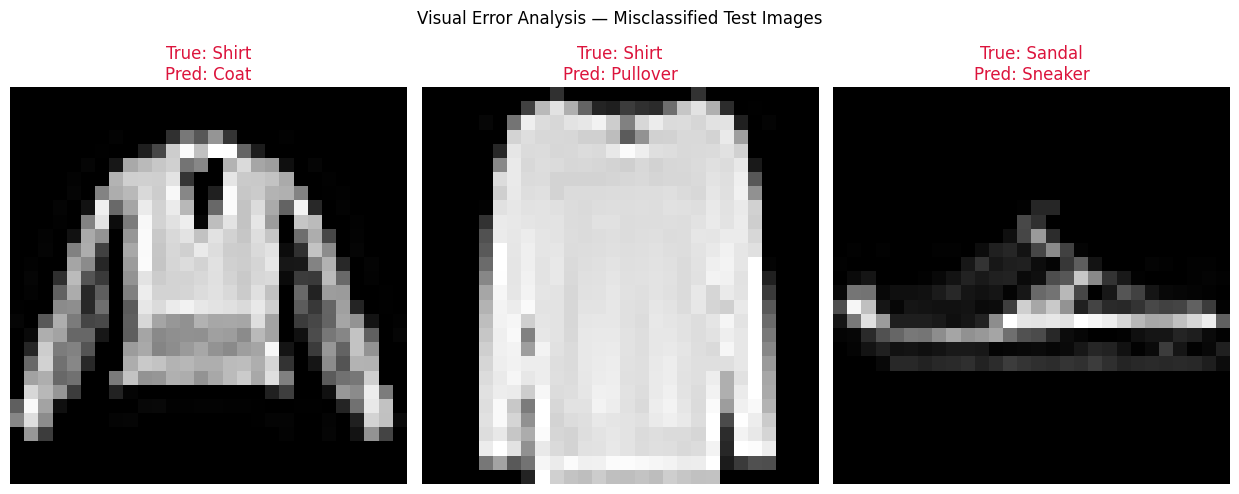

In [14]:
# ============================================================
# 13. VISUAL ERROR ANALYSIS — 3 RANDOM ERRORS
# ============================================================

wrong_idx = np.where(
    test_preds != test_targets
)[0]

if len(wrong_idx) >= 3:

    rng = np.random.default_rng(
        SEED
    )

    picks = rng.choice(
        wrong_idx,
        size=3,
        replace=False
    )

else:

    picks = wrong_idx

if len(picks) == 0:

    print(
        "No misclassified test images were found."
    )

else:

    plt.figure(
        figsize=(12.5, 5)
    )

    for plot_no, idx in enumerate(
        picks,
        start=1
    ):

        image, true_label = (
            test_set[int(idx)]
        )

        display_image = (
            denormalize(
                image
            )
            .squeeze(0)
            .numpy()
        )

        plt.subplot(
            1,
            len(picks),
            plot_no
        )

        plt.imshow(
            display_image,
            cmap="gray"
        )

        plt.title(
            f"True: {CLASS_NAMES[test_targets[idx]]}\n"
            f"Pred: {CLASS_NAMES[test_preds[idx]]}",
            color="crimson"
        )

        plt.axis("off")

    plt.suptitle(
        "Visual Error Analysis — Misclassified Test Images"
    )

    plt.tight_layout(
        rect=(0, 0, 1, 0.92)
    )

    plt.show()


# 14. Real-World Custom Phone Image Testing

A phone photo has a large domain gap compared with FashionMNIST: it is usually RGB, high-resolution, may have a light background, and may contain large empty margins.

The preparation below reduces that gap **before** the same `EVAL_TRANSFORM` is used.


In [22]:
# ============================================================
# 14. CUSTOM IMAGE PREPROCESSING HELPERS
# ============================================================

def _should_invert(gray_img, border_frac=0.12):
    arr = np.asarray(gray_img, dtype=np.float32)
    height, width = arr.shape
    bh = max(1, int(height * border_frac))
    bw = max(1, int(width * border_frac))
    border = np.concatenate([
        arr[:bh, :].ravel(), arr[-bh:, :].ravel(),
        arr[:, :bw].ravel(), arr[:, -bw:].ravel()
    ])
    cy0, cy1 = int(height * 0.30), int(height * 0.70)
    cx0, cx1 = int(width * 0.30), int(width * 0.70)
    centre = arr[cy0:cy1, cx0:cx1]
    return float(np.median(border)) > float(np.median(centre))

def _crop_to_object(gray_img, pad_frac=0.06):
    arr = np.asarray(gray_img, dtype=np.float32)
    threshold = arr.mean() + 0.35 * arr.std()
    mask = arr > threshold
    if mask.sum() < 32: return gray_img
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    top, bottom = rows[0], rows[-1]
    left, right = cols[0], cols[-1]
    side = max(bottom - top + 1, right - left + 1)
    pad = max(1, int(side * pad_frac))
    side += 2 * pad
    cy, cx = (top + bottom) // 2, (left + right) // 2
    return gray_img.crop((cx - side//2, cy - side//2, cx + side//2, cy + side//2))

def prepare_photo(path, invert="auto", autocrop=True):
    raw = ImageOps.exif_transpose(Image.open(path))
    gray = raw.convert("L")
    do_invert = _should_invert(gray) if invert == "auto" else bool(invert)
    if do_invert: gray = ImageOps.invert(gray)
    if autocrop: gray = _crop_to_object(gray)
    gray = ImageOps.autocontrast(gray, cutoff=1)
    return gray, {"source_size": raw.size, "inverted": do_invert, "autocropped": autocrop}

def label_from_filename(filename):
    # Fix: replace '-' with '' or '_' to match CLASS_SLUGS
    stem = Path(filename).stem.lower().replace('-', '')
    parts = stem.split("_")
    for part in parts:
        if part in SLUG_TO_IDX: return SLUG_TO_IDX[part]
    return None

print("✅ Preprocessing helpers updated to handle hyphens.")

✅ Preprocessing helpers updated to handle hyphens.


In [23]:
# Update slug mapping to handle individual components of 'ankle_boot'
SLUG_TO_IDX['ankle_boot'] = SLUG_TO_IDX['ankleboot']
SLUG_TO_IDX['ankle'] = SLUG_TO_IDX['ankleboot']
SLUG_TO_IDX['boot'] = SLUG_TO_IDX['ankleboot']

custom_records = []

for path in PHOTO_FILES:
    prepared, info = prepare_photo(
        path,
        invert="auto",
        autocrop=True
    )

    tensor = EVAL_TRANSFORM(
        prepared
    )

    # This now uses the fixed label_from_filename
    true_label = label_from_filename(
        path.name
    )

    custom_records.append({
        "path": path,
        "prepared": prepared,
        "tensor": tensor,
        "true_idx": true_label,
        "info": info
    })

print(f"Prepared {len(custom_records)} custom images.")

for record in custom_records:
    true_idx = record["true_idx"]
    true_name = (
        CLASS_NAMES[true_idx]
        if true_idx is not None
        else "unknown"
    )

    print(
        f"{record['path'].name:30s} "
        f"-> true label: {true_name:12s} "
        f"| inverted={record['info']['inverted']} "
        f"| cropped={record['info']['autocropped']}"
    )

Prepared 10 custom images.
01_t-shirt.png                 -> true label: T-shirt/top  | inverted=False | cropped=True
02_trouser.jpg                 -> true label: Trouser      | inverted=True | cropped=True
03_pullover.jpg                -> true label: Pullover     | inverted=True | cropped=True
04_dress.jpg                   -> true label: Dress        | inverted=True | cropped=True
05_coat.jpg                    -> true label: Coat         | inverted=True | cropped=True
06_sandal.jpg                  -> true label: Sandal       | inverted=True | cropped=True
07_shirt.jpg                   -> true label: Shirt        | inverted=True | cropped=True
08_sneaker.jpg                 -> true label: Sneaker      | inverted=True | cropped=True
09_bag.jpg                     -> true label: Bag          | inverted=True | cropped=True
10_ankle_boot.jpg              -> true label: Ankle boot   | inverted=True | cropped=True


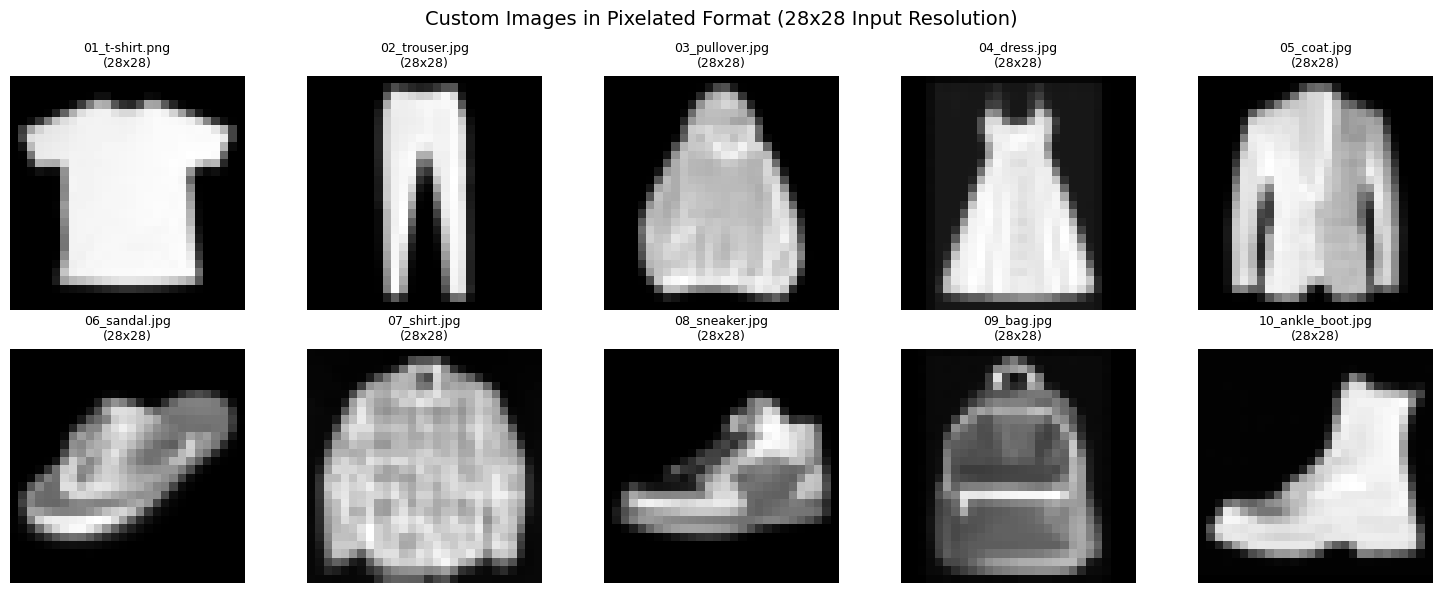

In [17]:
# 18. PREPROCESSING PREVIEW (Pixelated 28x28 Format)
plt.figure(figsize=(15, 6))
for i, record in enumerate(custom_records, 1):
    plt.subplot(2, 5, i)
    # Denormalize the tensor to show the actual 28x28 pixel values
    pixelated_img = denormalize(record['tensor']).squeeze(0).numpy()
    plt.imshow(pixelated_img, cmap="gray", interpolation='nearest')
    plt.title(f"{record['path'].name}\n(28x28)", fontsize=9)
    plt.axis("off")

plt.suptitle("Custom Images in Pixelated Format (28x28 Input Resolution)", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# Refresh predictions with updated labels for all 10 images
custom_batch = torch.stack([
    record["tensor"]
    for record in custom_records
]).to(device)

model.eval()
with torch.no_grad():
    logits = model(custom_batch)
    probabilities = torch.softmax(logits, dim=1)
    predicted_indices = probabilities.argmax(dim=1)
    confidence_scores = probabilities.max(dim=1).values

print("CUSTOM SMARTPHONE PREDICTIONS (FULLY UPDATED)")
print("=" * 105)

for i, record in enumerate(custom_records):
    predicted_idx = predicted_indices[i].item()
    predicted_name = CLASS_NAMES[predicted_idx]
    confidence = confidence_scores[i].item() * 100
    true_idx = record["true_idx"]

    if true_idx is not None:
        true_name = CLASS_NAMES[true_idx]
        correct_text = "✓" if true_idx == predicted_idx else "✗"
        print(f"{record['path'].name:30s} | True: {true_name:12s} | Pred: {predicted_name:12s} | Conf: {confidence:6.2f}% {correct_text}")
    else:
        print(f"{record['path'].name:30s} | True: {'unknown':12s} | Pred: {predicted_name:12s} | Conf: {confidence:6.2f}%")

CUSTOM SMARTPHONE PREDICTIONS (FULLY UPDATED)
01_t-shirt.png                 | True: T-shirt/top  | Pred: T-shirt/top  | Conf:  94.08% ✓
02_trouser.jpg                 | True: Trouser      | Pred: Trouser      | Conf: 100.00% ✓
03_pullover.jpg                | True: Pullover     | Pred: Coat         | Conf:  82.10% ✗
04_dress.jpg                   | True: Dress        | Pred: Dress        | Conf:  69.78% ✓
05_coat.jpg                    | True: Coat         | Pred: Shirt        | Conf:  68.79% ✗
06_sandal.jpg                  | True: Sandal       | Pred: Sandal       | Conf:  72.46% ✓
07_shirt.jpg                   | True: Shirt        | Pred: Shirt        | Conf:  55.05% ✓
08_sneaker.jpg                 | True: Sneaker      | Pred: Sneaker      | Conf:  90.30% ✓
09_bag.jpg                     | True: Bag          | Pred: Bag          | Conf:  68.81% ✓
10_ankle_boot.jpg              | True: Ankle boot   | Pred: Ankle boot   | Conf:  99.78% ✓


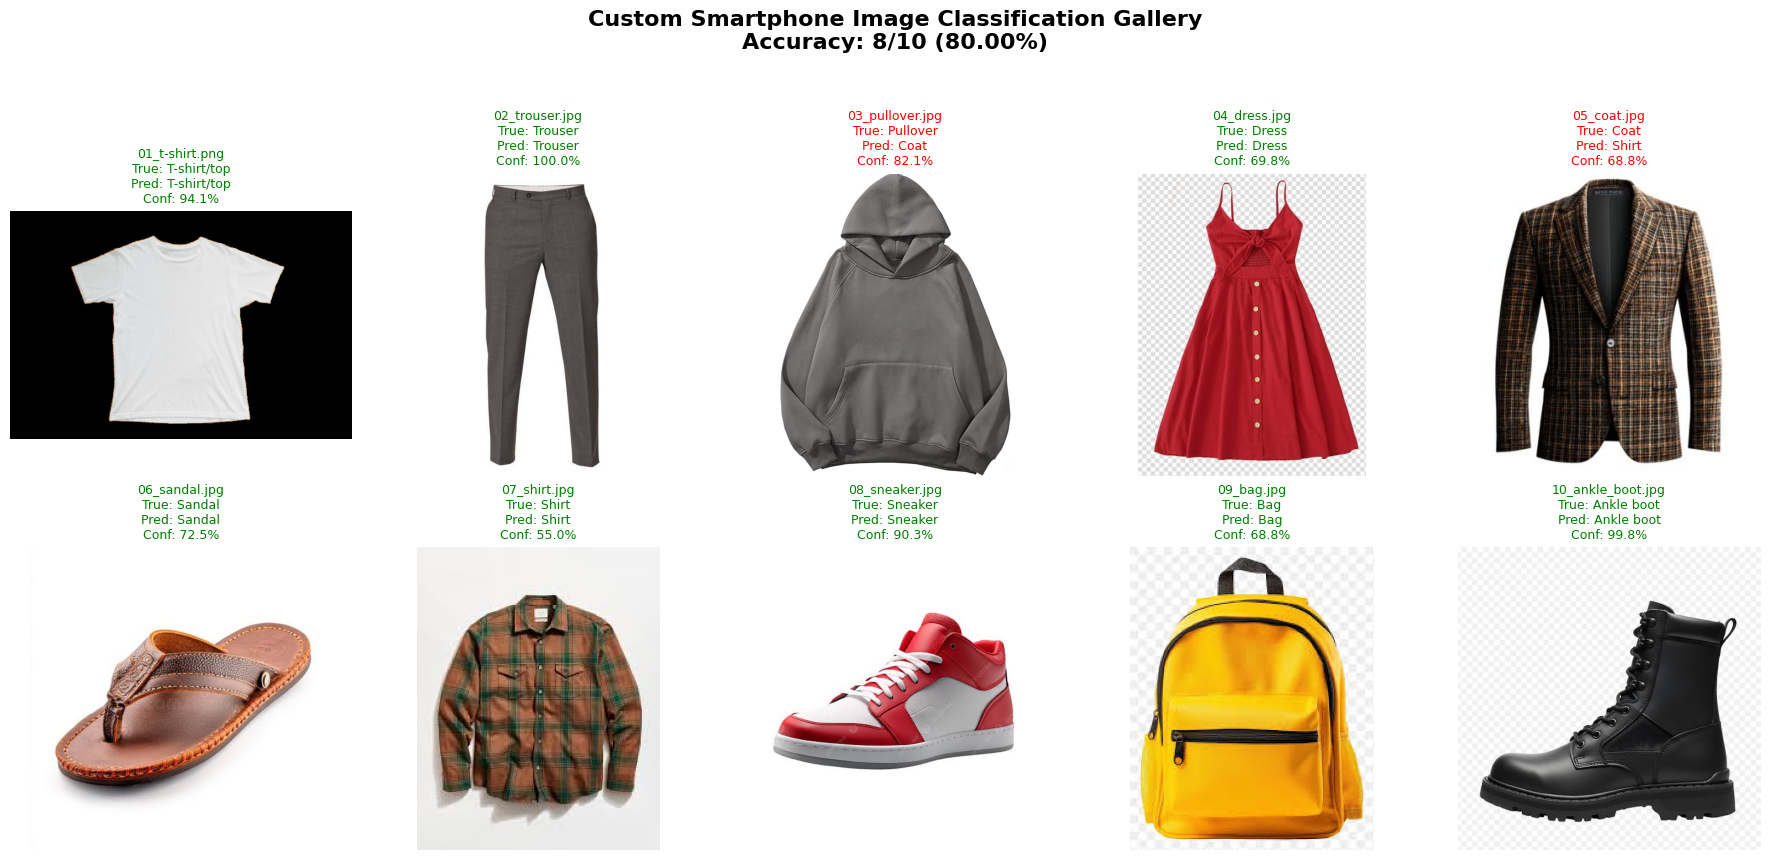

In [25]:
# Re-generate gallery to show updated accuracy
fig, axes = plt.subplots(2, 5, figsize=(18, 9))
axes = axes.flatten()

known_correct = 0
known_total = 0

for i, record in enumerate(custom_records):
    predicted_idx = predicted_indices[i].item()
    true_idx = record["true_idx"]
    if true_idx is not None:
        known_total += 1
        if true_idx == predicted_idx:
            known_correct += 1

accuracy_str = f"\nAccuracy: {known_correct}/{known_total} ({(known_correct/known_total)*100:.2f}%)" if known_total > 0 else ""

for i, record in enumerate(custom_records):
    raw_image = Image.open(record["path"]).convert("RGB")
    predicted_idx = predicted_indices[i].item()
    predicted_name = CLASS_NAMES[predicted_idx]
    confidence = confidence_scores[i].item() * 100
    true_idx = record["true_idx"]

    if true_idx is not None:
        title = f"True: {CLASS_NAMES[true_idx]}\nPred: {predicted_name}\nConf: {confidence:.1f}%"
        color = "green" if true_idx == predicted_idx else "red"
    else:
        title = f"Pred: {predicted_name}\nConf: {confidence:.1f}%"
        color = "black"

    axes[i].imshow(raw_image)
    axes[i].set_title(f"{record['path'].name}\n{title}", fontsize=9, color=color)
    axes[i].axis("off")

plt.suptitle(f"Custom Smartphone Image Classification Gallery{accuracy_str}", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [26]:
# Print final report with updated numbers
print("=" * 105)
print("CNN IMAGE CLASSIFICATION WITH PYTORCH — FINAL REPORT")
print("=" * 105)
print(f"Test accuracy       : {test_accuracy * 100:.2f}%")
print("Custom images       :", len(custom_records))
if known_total > 0:
    print(f"Custom known-label  : {known_correct}/{known_total} ({known_correct / known_total * 100:.2f}%)")
print("=" * 105)

CNN IMAGE CLASSIFICATION WITH PYTORCH — FINAL REPORT
Test accuracy       : 91.75%
Custom images       : 10
Custom known-label  : 8/10 (80.00%)
